# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

Completen al menos una entrada por bloque importante del trabajo.

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus |Obtención del corpus|Compartí ideas sueltas y URLs y pedí opinión sobre su pertinencia|Identificó noticias relevantes para utilizar. Además, nuevamente, tuve problemas con la generación del corpus con playwright |El código sugerido para corregir el error del playwright, ya que nuevamente tenía problemas con descargar el archivo final tras el scraping |Descarté una noticia interesante de La Nación por una limitación propia en el uso de ese sitio, ya que al parecer agoté los límites de lectura. Así que ahi decidí cambiar La Nación Clarín.
| Procesamiento con spaCy |Resolver error de scraping |El texto de Página 12 trae menú de navegación en lugar del artículo con trafilatura, ¿qué podemos revisar? |Propuso BeautifulSoup, luego Playwright como alternativa |Opté por Playwright directamente, ya que el sitio de Página 12 es dinámico |Descarté BeautifulSoup por ser insuficiente para este tipo de sitios |
| Representaciones sparse |Entender la diferencia entre BoW y TF-IDF |Le consulté por qué TF-IDF muestra mejor el contraste que la frecuencia sola|Explicó que TF-IDF penaliza términos compartidos entre grupos y premia los distintivos, revelando el encuadre real de cada medio |La explicación sirvió para el ítem 10|-|
| Visualización |Existencia de términos que no eran de la noticia en sí|Es posible que haya extraído términos de más de cada noticia?|Limpieza del corpus |- |Dejo en pausa la limpieza por esta entrega |
| Interpretación final |Revisión de la redacción de la interpretación|Compartí mis observaciones ("economía pero a qué costo" es la frase que le mencioné como cierre) y pedí ayuda para revisar la redacción y lógica.|Propuso correcciones de frases.| Correcciones de algunas frases.|Algunos términos o frases que sentía que no aportaban a la interpretación o que alucinaba.|


## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [1]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
%pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper scikit-learn yt-dlp gradio -q
!python -m spacy download es_core_news_lg -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\cin_c\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\cin_c\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [3]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_raw.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_lg"
TOP_N = 12               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")


Ruta esperada del corpus: corpus_raw.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [4]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Documentos cargados: 6
Grupos detectados: ['clarin', 'pagina12']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,p12_01,2025-05-12,Página 12,Redacción,La Corte Suprema de Santa Fe reconoció el daño genético provocado por el glifosato,pagina12,553
1,p12_02,2019-06-01,Página 12,Redacción,Glifosato: una investigación argentina confirma su peligro,pagina12,1050
2,p12_03,2020-03-01,Página 12,Redacción,Nuevo estudio vincula al glifosato con el cáncer y malformaciones,pagina12,790
3,cla_01,2025-08-29,Clarín,Ernesto Azarkevich,Los productores podrán seguir usando glifosato en Misiones,clarin,748
4,cla_02,2020-08-28,Clarín,Héctor Huergo,La soja RR y el glifosato,clarin,1312
5,cla_03,2022-11-06,Clarín,Redacción,Qué es el glifosato y cuál es su impacto en la economía y en la ecología,clarin,838


In [6]:
# Ver el inicio del texto del primer artículo de Página 12
print(df[df["grupo_comparacion"] == "pagina12"]["texto"].iloc[0][:500])

La Corte Suprema de Santa Fe ratificó un fallo que reconoce el daño genético causado por la exposición al glifosato, un componente tóxico presente en herbicidas. De esta manera ratificó que, entre otras cosas, una sentencia ordena una distancia mínima de mil metros para pulverizar productos con este tipo de tóxicos.


Esta problemática no es algo reciente, sino que se viene estudiando desde hace años. En 2022, la Red Interuniversitaria en Ambiente y Salud de la Región Centro (REDINASCE), publicó


In [7]:
print(df[df["grupo_comparacion"] == "clarin"]["texto"].iloc[0][:500])

ERNESTO
AZARKEVICH
CORRESPONSALÍA MISIONES
Escuchar
Resumen
Compartir
Seguir
1
Comentar
29/08/2025 15:01

El Gobierno de Misiones decidió dar marcha atrás con la prohibición del uso del glifosato a partir de 2030 y lo supeditó a la aprobación por parte de organismos nacionales e internacionales. Esta es la segunda prórroga que fija el Gobierno para reemplazar definitivamente el uso del popular herbicida.

Con este decreto, el Gobierno busca también llevar certidumbre a los mercados internacional


In [8]:
print(df.columns.tolist())

['id', 'fecha', 'medio', 'autor', 'titulo', 'url', 'grupo_comparacion', 'texto', 'num_palabras']


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


Este trabajo compara cómo Clarín y Página 12 cubrieron el debate sobre el glifosato en Argentina durante los últimos cinco años (2019-2025). El glifosato tiene presencia en el país desde hace décadas, pero el debate público sobre sus riesgos para la salud y el ambiente sigue vigente y genera coberturas periodísticas muy distintas según el medio.
Página 12 no lo había utilizado en los trabajos anteriores y sus titulares sobre el tema me resultaron llamativos desde la búsqueda inicial. Clarín fue elegido como reemplazo de La Nación - descartada por límites de acceso gratuito - y me llamó la atención porque al buscar artículos sobre glifosato, términos como "cáncer" directamente no aparecen en sus coberturas, lo que ya sugiere una diferencia de encuadre antes de cualquier análisis de este trabajo.
Ambos son medios masivos argentinos con cobertura nacional, y los artículos seleccionados abordan el mismo objeto - el glifosato - en un período similar. Eso permite contrastar cómo cada medio construye discursivamente el mismo tema.
En cuanto a los límites del recorte, primero, la selección de artículos tiene una carga subjetiva, lo que genera una mirada sesgada. Segundo, con solo tres artículos por grupo el corpus es mínimo y los resultados cuantitativos deben leerse con cautela. Tercero, los artículos de cada grupo no cubren exactamente los mismos eventos, lo que hace que una parte del contraste refleje diferencias de agenda más que de encuadre sobre un mismo hecho.

## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [9]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,6
1,palabras aproximadas,5291
2,promedio por texto,881.8
3,grupo 1,clarin
4,grupo 2,pagina12


In [10]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,clarin,3,2898,966.000000
1,pagina12,3,2393,797.666667


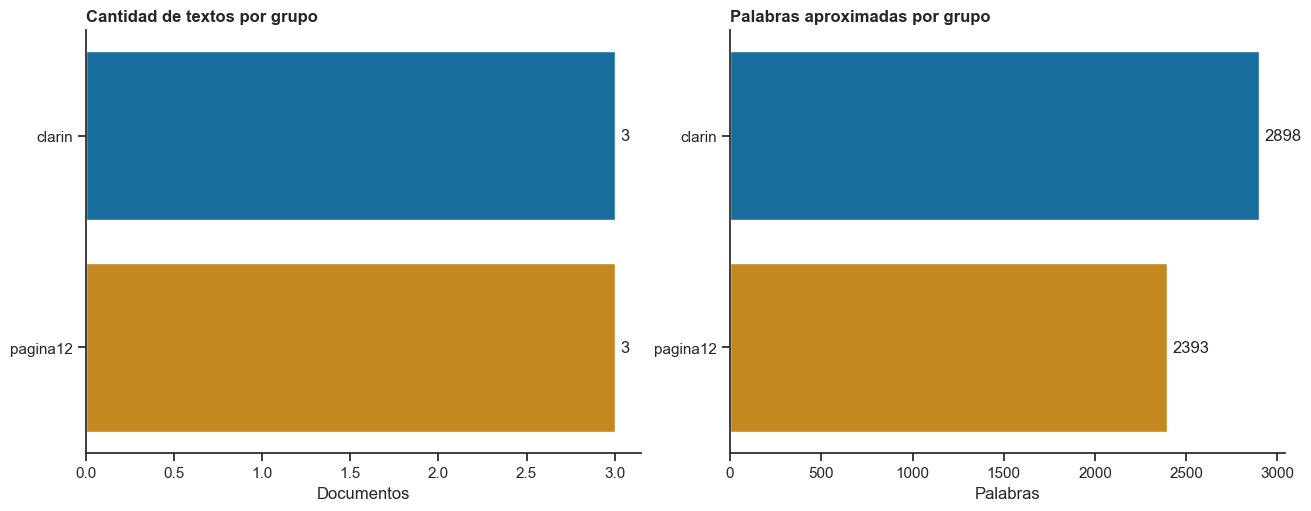

In [11]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [12]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


Modelo cargado correctamente: es_core_news_lg


In [13]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())


,titulo,grupo_comparacion,texto_contenido
0,La Corte Suprema de Santa Fe reconoció el daño genético provocado por el glifosato,pagina12,corte suprema santa fe ratificar fallo reconocer daño genético causado exposición glifosato componente tóxico presente herbicida ratific...
1,Glifosato: una investigación argentina confirma su peligro,pagina12,resultado presentado deber motivo preocupación sistema responsable salud humano vida silvestre alertar trabajo científico inédito nivel ...
2,Nuevo estudio vincula al glifosato con el cáncer y malformaciones,pagina12,estudio científico efecto glifosato ambiente salud detallado reciente recopilación impacto sanitario herbicida utilizado mundo pilar mod...
3,Los productores podrán seguir usando glifosato en Misiones,clarin,ernesto azarkevich corresponsalía misión escuchar resumen compartir seguir comentar gobierno misiones decidir marcha atrás prohibición g...
4,La soja RR y el glifosato,clarin,héctor huergo resumen compartir seguir comentar actualizado hito fundamental saga soja aparición gen rr otorgar tolerancia herbicida gli...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [14]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,clarin,glifosato,25
1,clarin,soja,18
2,clarin,clarín,13
3,clarin,misiones,10
4,clarin,salud,9
5,clarin,argentina,9
6,clarin,ambiente,8
7,clarin,rr,8
8,clarin,monsanto,8
9,clarin,herbicida,7


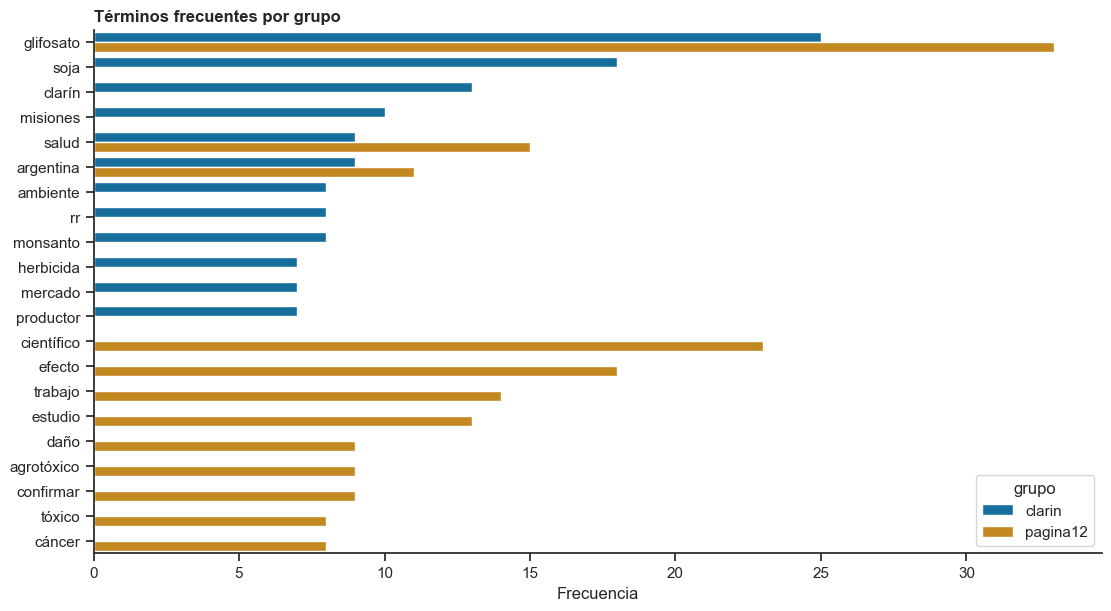

In [15]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [16]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
98,clarin,Monsanto,ORG,8
111,clarin,RR,ORG,7
137,clarin,la Argentina,LOC,6
96,clarin,Misiones,LOC,5
86,clarin,Leguizamón,PER,4
8,clarin,Aldosivi,ORG,3
10,clarin,Alepo,LOC,3
20,clarin,Clarín,MISC,3
22,clarin,Colapinto,PER,3
34,clarin,Diputados,ORG,3


In [17]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,clarin,millón tonelada,4
1,clarin,amigabl ambiente,4
2,clarin,siembra directo,4
3,clarin,vivo mano,3
4,clarin,hora probable,3
5,clarin,ingreso tendencia,3
6,clarin,adorni preparar,3
7,clarin,vivo hora,3
8,clarin,interesar tiempo,3
9,clarin,hablar cfd,3


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [18]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,clarin,ernesto azarkevich corresponsalía misión escuchar resumen compartir seguir comentar gobierno misiones decidir marcha atrás prohibición g...
1,pagina12,corte suprema santa fe ratificar fallo reconocer daño genético causado exposición glifosato componente tóxico presente herbicida ratific...


In [19]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,clarin,rr,8.0
1,clarin,productor,7.0
2,clarin,mercado,7.0
3,clarin,maleza,7.0
4,clarin,directo,7.0
5,clarin,comentar,6.0
6,clarin,ia,6.0
7,clarin,milei,6.0
8,clarin,patrocinado,6.0
9,clarin,dinero,6.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,clarin,rr,0.1589
1,clarin,productor,0.1390
2,clarin,mercado,0.1390
3,clarin,maleza,0.1390
4,clarin,directo,0.1390
5,clarin,comentar,0.1191
6,clarin,ia,0.1191
7,clarin,milei,0.1191
8,clarin,patrocinado,0.1191
9,clarin,dinero,0.1191


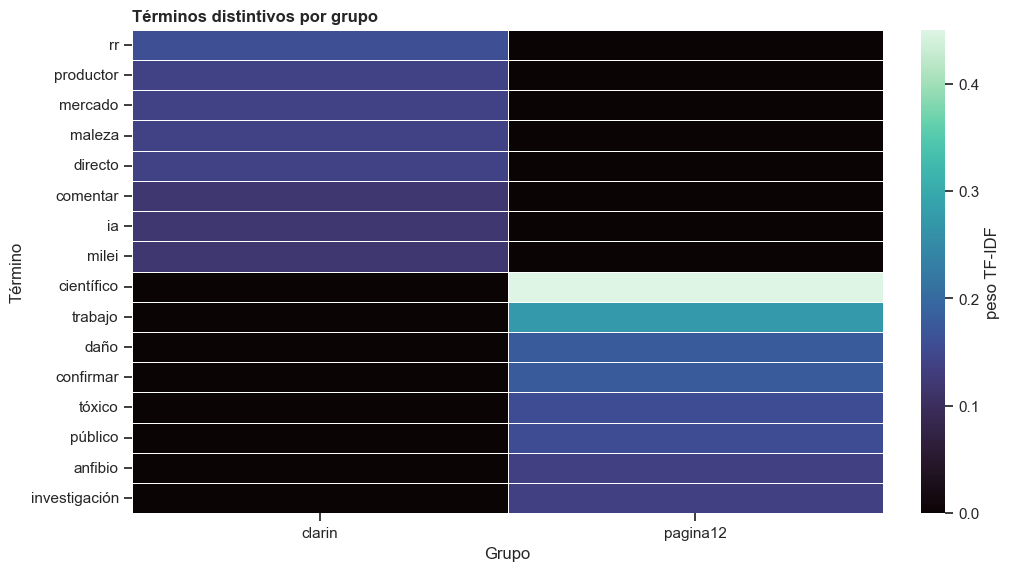

In [20]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [21]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,clarin,rr,0.1589
1,clarin,productor,0.1390
2,pagina12,científico,0.4501
3,pagina12,trabajo,0.2740


In [22]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,clarin,rr,La soja RR y el glifosato,...ir\nSeguir\n0\nComentar\n28/08/2020 13:35\n/ Actualizado al 11/09/2020 23:29\n\nEl hito fundamental de la saga de la soja fue la apar...
1,clarin,rr,Qué es el glifosato y cuál es su impacto en la economía y en la ecología,"...10 millones de toneladas. Esto iba a cambiar, radicalmente, desde 1996.\n\nEse año, el gobierno autorizó la siembra de la soja transg..."
2,clarin,productor,La soja RR y el glifosato,"...igatorio”, y que nadie controlaba porque no había con qué.\n\nCuando me encuentro con Jorge Ossana, recordamos aquella nota de 1973, ..."
3,pagina12,científico,Glifosato: una investigación argentina confirma su peligro,"...dos aquí deberían ser motivo de preocupación para los sistemas (responsables) de la salud humana y de la vida silvestre"", alerta un t..."
4,pagina12,trabajo,Glifosato: una investigación argentina confirma su peligro,"...presentados aquí deberían ser motivo de preocupación para los sistemas (responsables) de la salud humana y de la vida silvestre"", ale..."
5,pagina12,trabajo,Nuevo estudio vincula al glifosato con el cáncer y malformaciones,"...se suman familias y pueblos que denuncian los efectos de las fumigaciones.\n\n\n“Antología Toxicológica del Glifosato +1000”, es el t..."


## 10. Escritura interpretativa

Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**
   - ¿Qué comparan exactamente?
   - ¿Qué vuelve válidos esos dos grupos como contraste?

2. **Lectura distante**
   - ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
   - ¿Qué diferencias aparecen con más claridad cuando miran `TF-IDF` y no solo frecuencias?

3. **Lectura cercana**
   - ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
   - ¿Qué cambia cuando vuelven al fragmento?

4. **Visualización y método**
   - ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
   - ¿Qué límites tiene este enfoque para leer discurso?
   - ¿Qué no se puede afirmar solo con estas representaciones sparse?


1. Recorte y comparación
Este trabajo compara cómo Clarín y Página 12 construyen discursivamente el glifosato. Ambos son medios masivos argentinos que cubren el mismo objeto, pero desde encuadres muy distintos. Lo que los vuelve comparables es el tema compartido y la diferencia de perspectiva.

2. Lectura distante
Los términos más frecuentes y distintivos de Clarín organizan el glifosato desde una dimensión económica y productiva: "rr", "productor", "mercado", "maleza", "siembra directa". El herbicida aparece como herramienta del agronegocio, no como objeto de debate sanitario.
Página 12, en cambio, trabaja el tema desde la evidencia científica y sus consecuencias: "científico" es el término con mayor peso TF-IDF (0.45), seguido por "trabajo", "daño", "confirmar", "tóxico". Los bigramas "trabajo científico", "daño genético" y "enfermedad cáncer" refuerzan esto. El glifosato aparece como objeto de investigación con efectos documentados sobre la salud.
Con TF-IDF vemos esto con más claridad ya que los términos distintivos de cada uno revelan el encuadre real.

3. Lectura cercana
En Clarín, el término "rr" aparece en el contexto de la historia del gen Roundup Ready y su adopción en Argentina desde 1996. En el fragmento se menciona como un hito de la saga de la soja, con lo que ese término, además de una sigla, es un elemento productivo revolucionador. El encuadre es más económico.
En Página 12, el término "científico" aparece asociado a la advertencia de los resultados "deberían ser motivo de preocupación para los sistemas de salud humana y de la vida silvestre". Volver al fragmento muestra que Página 12 usa la autoridad científica para fundamentar una denuncia. El encuadre es científico-sanitario.

4. Visualización y método
El mapa de calor de TF-IDF fue el gráfico más útil para ver el contraste, porque permite ver de un vistazo qué vocabulario es exclusivo de cada grupo. El gráfico de frecuencias, en cambio, muestra términos compartidos que no distinguen.
En cuanto a los límites del enfoque: las representaciones sparse no afirman la causalidad entre el medio y la posición editorial. Además, el ruido del scraping introdujo términos ajenos al artículo ("patrocinado", "milei", "ia" en Clarín) que distorsionan algunos los resultados, también teniendo en cuenta que fueron 3 recortes de cada medio.

In [23]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
